# Эксперимент 5: Правильное соотношение сторон (224×1400)

**Ключевое изменение:** вместо квадратного resize 518×518 используем 224×1400.

- Оригинал: 256×1600, соотношение 1:6.25
- Было: 518×518 (квадрат) → горизонтальные дефекты сплющиваются
- Стало: 224×1400 (1:6.25) → структура дефектов сохраняется
- Патч-сетка: 16×100 (было 37×37), маска: 64×400 (было 148×148)
- Backbone: заморожен. Данные: 200 изображений.

> **v2** — исправлен баг: `JointTransform` применяет flip и crop **одновременно** к изображению и маске.

## 1. Импорты и конфигурация

In [1]:
import os, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import Counter
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics import JaccardIndex
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

print(f'Python: {sys.version}')
print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} Гб')

DATA_DIR      = 'C:/Users/ADMIN/Desktop/magistr/VKR/steel_defect/'
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images/')
save_dir      = 'C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads'
os.makedirs(save_dir, exist_ok=True)

# ── Ключевые параметры размера ─────────────────────────────────────────
IMG_H       = 224   # кратно 14, соотношение 1:6.25
IMG_W       = 1400  # кратно 14
PATCH_SIZE  = 14    # DINOv2 patch size
PATCH_H     = IMG_H // PATCH_SIZE   # 16
PATCH_W     = IMG_W // PATCH_SIZE   # 100
MASK_H      = PATCH_H * 4          # 64
MASK_W      = PATCH_W * 4          # 400
EMBED_DIM   = 768
NUM_CLASSES = 5
# ──────────────────────────────────────────────────────────────────────

BATCH_SIZE  = 4    # уменьшить до 2 если OOM
EPOCHS      = 75
LR_HEAD     = 1e-3
N_SELECT    = 200
TEST_SIZE   = 0.2

print(f'\nРазмер входа:    {IMG_H}x{IMG_W}  (соотношение 1:{IMG_W//IMG_H})')
print(f'Патч-сетка:      {PATCH_H}x{PATCH_W} = {PATCH_H*PATCH_W} патчей')
print(f'Маска (выход):   {MASK_H}x{MASK_W}')
print(f'Для сравнения — было: 37x37=1369 патчей, маска 148x148')
print(f'CSV: {os.path.exists(TRAIN_CSV)}  IMG_DIR: {os.path.exists(TRAIN_IMG_DIR)}')

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch: 2.12.0.dev20260408+cu128
Устройство: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.5 Гб

Размер входа:    224x1400  (соотношение 1:6)
Патч-сетка:      16x100 = 1600 патчей
Маска (выход):   64x400
Для сравнения — было: 37x37=1369 патчей, маска 148x148
CSV: True  IMG_DIR: True


## 2. Датасет и вспомогательные функции

In [2]:
train_df    = pd.read_csv(TRAIN_CSV)
labeled_ids = train_df['ImageId'].unique().tolist()
print(f'Строк: {len(train_df):,}  |  Изображений: {len(labeled_ids):,}')


def decode_rle(rle_string, shape=(256, 1600)):
    if pd.isna(rle_string) or not isinstance(rle_string, str):
        return np.zeros(shape, dtype=np.uint8)
    nums   = list(map(int, rle_string.strip().split()))
    starts = np.array(nums[0::2]) - 1
    lens   = np.array(nums[1::2])
    mask   = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for s, l in zip(starts, lens):
        mask[s:s+l] = 1
    return mask.reshape(shape, order='F')


def build_segmask(image_id, df, shape=(256, 1600)):
    mask = np.zeros(shape, dtype=np.uint8)
    for _, row in df[df['ImageId'] == image_id].iterrows():
        cls = int(row['ClassId'])
        m   = decode_rle(row['EncodedPixels'], shape)
        mask[m == 1] = cls
    return mask


def get_classes(img_id, df):
    rows = df[df['ImageId'] == img_id]
    return sorted(rows['ClassId'].dropna().astype(int).unique().tolist())


def get_label(img_id, df):
    cls = get_classes(img_id, df)
    return cls[0] if cls else 0


def compute_class_weights(image_ids, df, num_classes=NUM_CLASSES):
    px = Counter({c: 0 for c in range(num_classes)})
    for img_id in image_ids:
        mask = build_segmask(img_id, df)
        for c in range(num_classes):
            px[c] += int((mask == c).sum())
    total = sum(px.values())
    w = torch.tensor([total/(num_classes*(px[c]+1e-6)) for c in range(num_classes)])
    w = (w / w.mean()).clamp(min=0.1, max=5.0)
    print('Веса классов:')
    for c, v in enumerate(w):
        print(f'  {"Фон" if c==0 else f"Дефект {c}"}: {v:.3f}  ({px[c]:,} пикс.)')
    return w.to(DEVICE)


print('Вспомогательные функции определены.')

Строк: 7,095  |  Изображений: 6,666
Вспомогательные функции определены.


## 3. Dataset с правильным соотношением сторон

In [3]:
# Ключевое изменение: Resize((IMG_H, IMG_W)) вместо квадрата
# v2: JointTransform — flip и crop применяются к img и mask одновременно
FLIP_P      = 0.5
CROP_SCALE  = (0.85, 1.0)
BRIGHTNESS  = 0.3


class JointTransform:
    def __init__(self, img_h=IMG_H, img_w=IMG_W, is_train=True,
                 flip_p=FLIP_P, crop_scale=CROP_SCALE, brightness=BRIGHTNESS):
        self.img_h       = img_h
        self.img_w       = img_w
        self.is_train    = is_train
        self.flip_p      = flip_p
        self.crop_scale  = crop_scale
        self.color_jitter = transforms.ColorJitter(brightness=brightness)
        self.to_tensor   = transforms.ToTensor()
        self.normalize   = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, img_pil, mask_np):
        img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_np).resize(
            (self.img_w, self.img_h), Image.NEAREST)
        if self.is_train:
            if random.random() < self.flip_p:
                img_pil  = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
                mask_pil = mask_pil.transpose(Image.FLIP_LEFT_RIGHT)
            scale  = random.uniform(*self.crop_scale)
            crop_h = max(1, int(self.img_h * scale))
            crop_w = max(1, int(self.img_w * scale))
            top    = random.randint(0, self.img_h - crop_h)
            left   = random.randint(0, self.img_w - crop_w)
            img_pil  = img_pil.crop((left, top, left+crop_w, top+crop_h))
            mask_pil = mask_pil.crop((left, top, left+crop_w, top+crop_h))
            img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
            mask_pil = mask_pil.resize((self.img_w, self.img_h), Image.NEAREST)
            img_pil  = self.color_jitter(img_pil)
        img_t    = self.normalize(self.to_tensor(img_pil))
        mask_np2 = np.array(mask_pil, dtype=np.uint8)
        return img_t, mask_np2


train_jt = JointTransform(is_train=True)
val_jt   = JointTransform(is_train=False)


class SteelSegDataset(Dataset):
    def __init__(self, ids, img_dir, df, joint_transform):
        self.ids=ids; self.img_dir=img_dir; self.df=df
        self.jt=joint_transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
        mask   = build_segmask(img_id, self.df)
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0),
            size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, img_id


print(f'Dataset определён. Маска: {MASK_H}x{MASK_W}')
print(f'Аугментации: flip_p={FLIP_P}, crop={CROP_SCALE}, brightness={BRIGHTNESS}')

Dataset определён. Маска: 64x400
Аугментации: flip_p=0.5, crop=(0.85, 1.0), brightness=0.3


## 4. Загрузка DINOv2 (заморожен)

In [4]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14',
                        pretrained=True, verbose=False)
dinov2 = dinov2.to(DEVICE).eval()
for p in dinov2.parameters():
    p.requires_grad = False

total = sum(p.numel() for p in dinov2.parameters()) / 1e6
print(f'DINOv2 ViT-B/14: {total:.1f}М параметров (заморожен)')

# Проверка: DINOv2 корректно обрабатывает нестандартный размер входа
# (позиционные эмбеддинги интерполируются автоматически)
with torch.no_grad():
    test_img = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)
    out = dinov2.forward_features(test_img)
    pt  = out['x_norm_patchtokens']
print(f'Тест forward: вход {IMG_H}x{IMG_W} -> патч-токены {pt.shape}')
print(f'Ожидалось: (1, {PATCH_H*PATCH_W}, {EMBED_DIM})')
assert pt.shape == (1, PATCH_H*PATCH_W, EMBED_DIM), 'Размер не совпадает!'
print('OK')
del test_img, out, pt

C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 ViT-B/14: 86.6М параметров (заморожен)
Тест forward: вход 224x1400 -> патч-токены torch.Size([1, 1600, 768])
Ожидалось: (1, 1600, 768)
OK


## 5. Эмбеддинги из кэша (для отбора)

In [5]:
# Используем кэш из Эксп.3 (518x518) — только для KMeans-отбора,
# не для обучения, поэтому разница в размере входа не важна.
emb_cache = os.path.join(save_dir, 'embeddings.pt')

if os.path.exists(emb_cache):
    print('Загружаем эмбеддинги из кэша...')
    ckpt       = torch.load(emb_cache, map_location='cpu')
    embeddings = ckpt['embeddings']
    emb_ids    = ckpt['emb_ids']
    print(f'Загружено: {embeddings.shape}')
else:
    print('Кэш не найден — извлекаем эмбеддинги...')
    sq_transform = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    class _EmbDs(Dataset):
        def __init__(self, ids, d, t):
            self.ids=ids; self.d=d; self.t=t
        def __len__(self): return len(self.ids)
        def __getitem__(self, i):
            img = Image.open(os.path.join(self.d, self.ids[i])).convert('RGB')
            return self.t(img), self.ids[i]
    ds = _EmbDs(labeled_ids, TRAIN_IMG_DIR, sq_transform)
    dl = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0)
    embs, ids_out = [], []
    with torch.no_grad():
        for imgs, img_ids in tqdm(dl, desc='Эмбеддинги'):
            tok = dinov2.forward_features(imgs.to(DEVICE))['x_norm_clstoken']
            embs.append(tok.cpu()); ids_out.extend(img_ids)
    embeddings = torch.cat(embs, 0); emb_ids = ids_out
    torch.save({'embeddings': embeddings, 'emb_ids': emb_ids}, emb_cache)
    print(f'Сохранено: {embeddings.shape}')

Загружаем эмбеддинги из кэша...
Загружено: torch.Size([6666, 768])


## 6. Отбор 200 изображений

In [6]:
def lightly_active_select(embeddings, image_ids, n_select, seed=SEED):
    km = KMeans(n_clusters=n_select, random_state=seed, n_init=10)
    km.fit(embeddings.numpy())
    sel = []
    for k in range(n_select):
        m  = km.labels_ == k
        if not m.any(): continue
        c  = torch.tensor(km.cluster_centers_[k])
        ix = np.where(m)[0]
        sel.append(int(ix[torch.norm(embeddings[m]-c, dim=1).argmin().item()]))
    return [image_ids[i] for i in sel], sel


def stratified_active_select(embeddings, image_ids, df,
                              n_per_class=50, n_total=500):
    guaranteed = []
    for cls in [1, 2, 3, 4]:
        cids = [i for i in image_ids if cls in get_classes(i, df)]
        guaranteed.extend(random.sample(cids, min(n_per_class, len(cids))))
    guaranteed = list(set(guaranteed))
    remaining  = [i for i in image_ids if i not in guaranteed]
    n_km       = n_total - len(guaranteed)
    extra      = []
    if n_km > 0 and remaining:
        rm    = [image_ids.index(i) for i in remaining]
        extra, _ = lightly_active_select(embeddings[rm], remaining, n_km)
    result = guaranteed + extra
    print(f'Отбор: {len(guaranteed)} гарант. + {len(extra)} KMeans = {len(result)}')
    return result


all_labels  = [get_label(i, train_df) for i in labeled_ids]
train_ids, test_ids = train_test_split(
    labeled_ids, test_size=TEST_SIZE, stratify=all_labels, random_state=SEED)
print(f'Train pool: {len(train_ids):,}  |  Test: {len(test_ids):,}')

pool_mask    = [emb_ids.index(i) for i in train_ids]
pool_embeds  = embeddings[pool_mask]
selected_ids = stratified_active_select(
    pool_embeds, train_ids, train_df, n_per_class=50, n_total=N_SELECT)

Train pool: 5,332  |  Test: 1,334
Отбор: 199 гарант. + 1 KMeans = 200


## 7. Архитектура: SegHeadNonSquare

In [7]:
class SegHeadNonSquare(nn.Module):
    """
    Декодер для нестандартного патч-грида (PATCH_H x PATCH_W).
    Вход:  патч-токены (B, PATCH_H*PATCH_W, EMBED_DIM)
    Выход: карта сегментации (B, NUM_CLASSES, MASK_H, MASK_W)
    Апсемплинг: PATCH_H->MASK_H (x4), PATCH_W->MASK_W (x4)
    """
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W):
        super().__init__()
        self.patch_h = patch_h
        self.patch_w = patch_w
        self.decoder = nn.Sequential(
            nn.Conv2d(embed_dim, 256, 1),
            nn.BatchNorm2d(256), nn.GELU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, num_classes, 1),
        )

    def forward(self, pt):
        B, N, C = pt.shape
        # Раскладываем токены в 2D сетку нужной формы
        x = pt.reshape(B, self.patch_h, self.patch_w, C).permute(0,3,1,2)
        return self.decoder(x)  # (B, num_classes, patch_h*4, patch_w*4)


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.s=smooth
    def forward(self, logits, targets):
        p       = F.softmax(logits, dim=1)
        B,C,H,W = p.shape
        t       = F.one_hot(targets, C).permute(0,3,1,2).float()
        i       = (p*t).sum(dim=(2,3))
        u       = p.sum(dim=(2,3)) + t.sum(dim=(2,3))
        return 1 - ((2*i+self.s)/(u+self.s)).mean()


_h = SegHeadNonSquare().to(DEVICE)
n  = sum(p.numel() for p in _h.parameters())
# Проверка формы выхода
with torch.no_grad():
    dummy = torch.randn(2, PATCH_H*PATCH_W, EMBED_DIM).to(DEVICE)
    out   = _h(dummy)
print(f'SegHeadNonSquare: {n:,} параметров')
print(f'Выход декодера: {tuple(out.shape)}  (ожидалось: (2, {NUM_CLASSES}, {MASK_H}, {MASK_W}))')
del _h, dummy, out

SegHeadNonSquare: 566,917 параметров
Выход декодера: (2, 5, 64, 400)  (ожидалось: (2, 5, 64, 400))


## 8. Функция обучения

In [8]:
def train_head(train_ids, val_ids, df,
               n_epochs=EPOCHS, lr=LR_HEAD, label='',
               checkpoint_every=25):
    head  = SegHeadNonSquare().to(DEVICE)
    opt   = optim.AdamW(head.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    cw    = compute_class_weights(train_ids, df)
    cce   = nn.CrossEntropyLoss(weight=cw)
    cdice = DiceLoss()

    tds = SteelSegDataset(train_ids, TRAIN_IMG_DIR, df, train_jt)
    vds = SteelSegDataset(val_ids,   TRAIN_IMG_DIR, df, val_jt)
    tdl = DataLoader(tds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    vdl = DataLoader(vds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    iou  = JaccardIndex(task='multiclass', num_classes=NUM_CLASSES,
                        average='none').to(DEVICE)
    hist = {'train_loss': [], 'val_miou': [], 'val_iou_per_class': []}
    best = 0.0
    print(f'Обучающих: {len(tds)}  |  Валидационных: {len(vds)}')
    print(f'Вход: {IMG_H}x{IMG_W}  Маска: {MASK_H}x{MASK_W}')

    for ep in range(1, n_epochs+1):
        head.train(); tl = 0.0
        for imgs, masks, _ in tdl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with torch.no_grad():
                pts = dinov2.forward_features(imgs)['x_norm_patchtokens']
            lg   = head(pts)
            loss = cce(lg, masks) + 0.5 * cdice(lg, masks)
            opt.zero_grad(); loss.backward(); opt.step()
            tl  += loss.item()
        sched.step()

        head.eval(); iou.reset()
        with torch.no_grad():
            for imgs, masks, _ in vdl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                pts = dinov2.forward_features(imgs)['x_norm_patchtokens']
                iou.update(head(pts).argmax(1), masks)
        ipc = iou.compute().cpu().numpy()
        mi  = float(ipc.mean())
        hist['train_loss'].append(tl/len(tdl))
        hist['val_miou'].append(mi)
        hist['val_iou_per_class'].append(ipc.tolist())
        if mi > best: best = mi

        if ep % 10 == 0 or ep == 1:
            s = '  '.join([f'cls{i}:{v:.3f}' for i,v in enumerate(ipc)])
            print(f'[{label}] Эп {ep:3d}/{n_epochs} | '
                  f'Loss:{tl/len(tdl):.4f} | mIoU:{mi:.4f} | {s}')

        if ep % checkpoint_every == 0:
            ckpt_path = os.path.join(save_dir, f'ckpt_{label}_v2_ep{ep}.pt')
            torch.save({'epoch':ep, 'model_state':head.state_dict(),
                        'history':hist, 'best_miou':best}, ckpt_path)
            print(f'  Чекпоинт: {ckpt_path}')

    print(f'\n  -> Лучший mIoU: {best:.4f}')
    return head, hist


print('Функция обучения определена.')

Функция обучения определена.


## 9. Обучение

In [9]:
print('='*60)
print(f'ЭКСП.5: {N_SELECT} реальных, вход {IMG_H}x{IMG_W}, маска {MASK_H}x{MASK_W}')
print('='*60)
model_ar, history_ar = train_head(
    selected_ids, test_ids, train_df,
    label=f'AspectRatio-{IMG_H}x{IMG_W}'
)

ЭКСП.5: 200 реальных, вход 224x1400, маска 64x400
Веса классов:
  Фон: 0.100  (78,181,311 пикс.)
  Дефект 1: 1.991  (236,225 пикс.)
  Дефект 2: 2.428  (193,649 пикс.)
  Дефект 3: 0.257  (1,832,305 пикс.)
  Дефект 4: 0.318  (1,476,510 пикс.)
Обучающих: 200  |  Валидационных: 1334
Вход: 224x1400  Маска: 64x400
[AspectRatio-224x1400] Эп   1/75 | Loss:1.3799 | mIoU:0.3510 | cls0:0.912  cls1:0.030  cls2:0.011  cls3:0.298  cls4:0.503
[AspectRatio-224x1400] Эп  10/75 | Loss:0.5026 | mIoU:0.4252 | cls0:0.943  cls1:0.145  cls2:0.124  cls3:0.416  cls4:0.499
[AspectRatio-224x1400] Эп  20/75 | Loss:0.3132 | mIoU:0.4309 | cls0:0.950  cls1:0.140  cls2:0.078  cls3:0.456  cls4:0.531
  Чекпоинт: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads\ckpt_AspectRatio-224x1400_v2_ep25.pt
[AspectRatio-224x1400] Эп  30/75 | Loss:0.2202 | mIoU:0.4561 | cls0:0.952  cls1:0.118  cls2:0.210  cls3:0.432  cls4:0.568
[AspectRatio-224x1400] Эп  40/75 | Loss:0.1630 | mIoU:0.4865 | cls0:0.954  cls1:0.230  cls2:0.223  cls3:0.4

## 10. Сравнение

Базовый (Эксп.3, 200, квадрат 518x518): mIoU = 0.3757
Эксп.5   (200 реальных, 224x1400): mIoU = 0.5004
Прирост: +12.5%

  Класс           Базовый     AspRatio    Прирост
--------------------------------------------------
  Фон              0.9453       0.9574      +1.2%
  Дефект 1         0.1106       0.2532     +14.3%
  Дефект 2         0.0931       0.2861     +19.3%
  Дефект 3         0.2842       0.4451     +16.1%
  Дефект 4         0.4455       0.5603     +11.5%


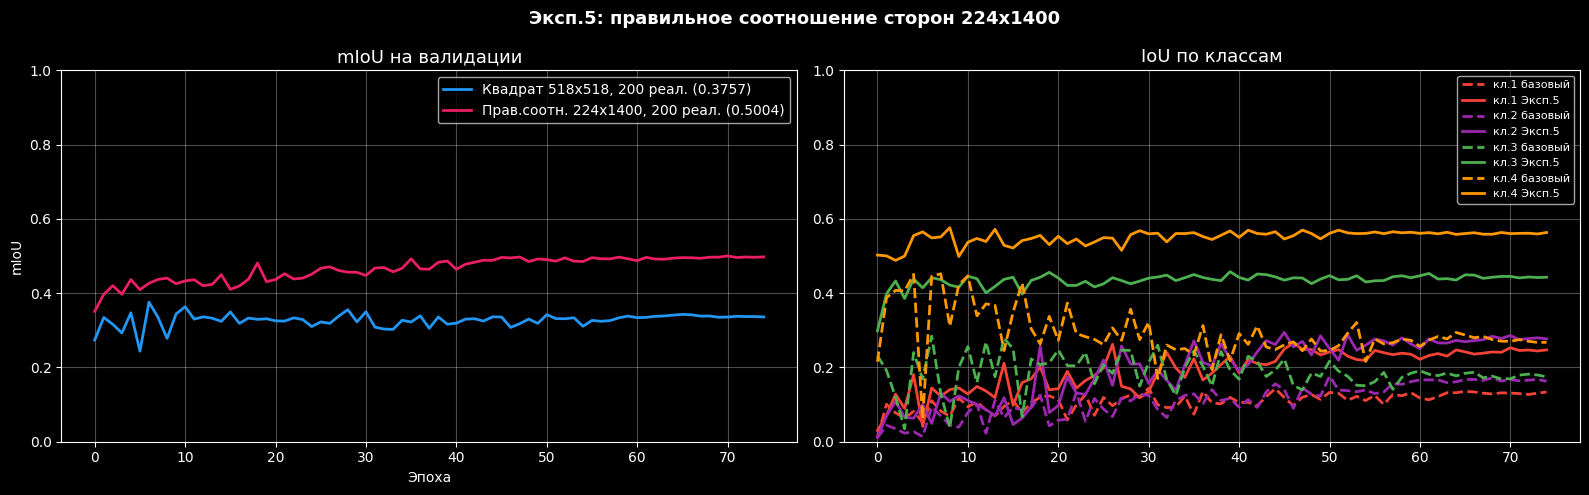

In [10]:
history_base_path = os.path.join(save_dir, 'history_base.json')
if os.path.exists(history_base_path):
    with open(history_base_path) as f:
        history_base = json.load(f)
    mb = max(history_base['val_miou'])
    eb = int(np.argmax(history_base['val_miou']))
    ib = history_base['val_iou_per_class'][eb]
    has_base = True
    print(f'Базовый (Эксп.3, 200, квадрат 518x518): mIoU = {mb:.4f}')
else:
    has_base = False

mar = max(history_ar['val_miou'])
ear = int(np.argmax(history_ar['val_miou']))
iar = history_ar['val_iou_per_class'][ear]
print(f'Эксп.5   ({N_SELECT} реальных, {IMG_H}x{IMG_W}): mIoU = {mar:.4f}')
if has_base:
    print(f'Прирост: {(mar-mb)*100:+.1f}%')

names = ['Фон','Дефект 1','Дефект 2','Дефект 3','Дефект 4']
print()
if has_base:
    print(f'  {"Класс":<12} {"Базовый":>10} {"AspRatio":>12} {"Прирост":>10}')
    print('-'*50)
    for c,(b,ar) in enumerate(zip(ib, iar)):
        print(f'  {names[c]:<12} {b:>10.4f} {ar:>12.4f} {(ar-b)*100:>+9.1f}%')
else:
    for c, ar in enumerate(iar):
        print(f'  {names[c]:<12} {ar:>12.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
if has_base:
    axes[0].plot(history_base['val_miou'], color='#2196F3', lw=2,
                 label=f'Квадрат 518x518, 200 реал. ({mb:.4f})')
axes[0].plot(history_ar['val_miou'], color='#E91E63', lw=2,
             label=f'Прав.соотн. {IMG_H}x{IMG_W}, {N_SELECT} реал. ({mar:.4f})')
axes[0].set_title('mIoU на валидации', fontsize=13)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('mIoU')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0, 1)

colors_cls = {1:'#F44336', 2:'#9C27B0', 3:'#4CAF50', 4:'#FF9800'}
for cls, col in colors_cls.items():
    if has_base:
        axes[1].plot([h[cls] for h in history_base['val_iou_per_class']],
                     color=col, lw=2, ls='--', label=f'кл.{cls} базовый')
    axes[1].plot([h[cls] for h in history_ar['val_iou_per_class']],
                 color=col, lw=2, ls='-', label=f'кл.{cls} Эксп.5')
axes[1].set_title('IoU по классам', fontsize=13)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1)
plt.suptitle(f'Эксп.5: правильное соотношение сторон {IMG_H}x{IMG_W}',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Сохранение

In [11]:
torch.save(model_ar.state_dict(),
           os.path.join(save_dir, f'model_ar_{IMG_H}x{IMG_W}_v2.pt'))
with open(os.path.join(save_dir, 'history_ar_v2.json'), 'w') as f:
    json.dump(history_ar, f)
print(f'Сохранено в: {save_dir}')

Сохранено в: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads
